Script pour l'entrainement de Resnet (101, 50, 18), deux protocoles, rétinotopique en intégrant une transformation log-polaire lors du ré-entrainement,
cartesien image sans transformation mais l'on applique un masque circulaire sur l'image. 

Tester les 3 data sets :

> full (Imagenet image complète) (done)
> square(le plus petit carré contenant la bounding box) (done)
> focus (meilleur point de fixation après une saccade) (done)


In [1]:
from retinotopy import *

Running on GPU :  Tesla V100-SXM2-32GB #GPU= 1
Running on Jean Zay with Tesla V100-SXM2-32GB with DATAROOT='/lustre/fsn1/projects/rech/fsx/uvb28bo/data' and USER='uvb28bo' 


# Transfer learning

data_set_type='focus'
--------------------------------------------------
..................................................
Training resnet cached_data/2025-03-06_focus_resnet18_retino.pt
Loading model_path='cached_data/2025-03-06_bbox_resnet18_retino.pt'


loading .... cached_data/2025-03-06_bbox_resnet18_retino.pt


FileNotFoundError: [Errno 2] No such file or directory: '/lustre/fsn1/projects/rech/fsx/uvb28bo/data/Imagenet_focus_retino/val'

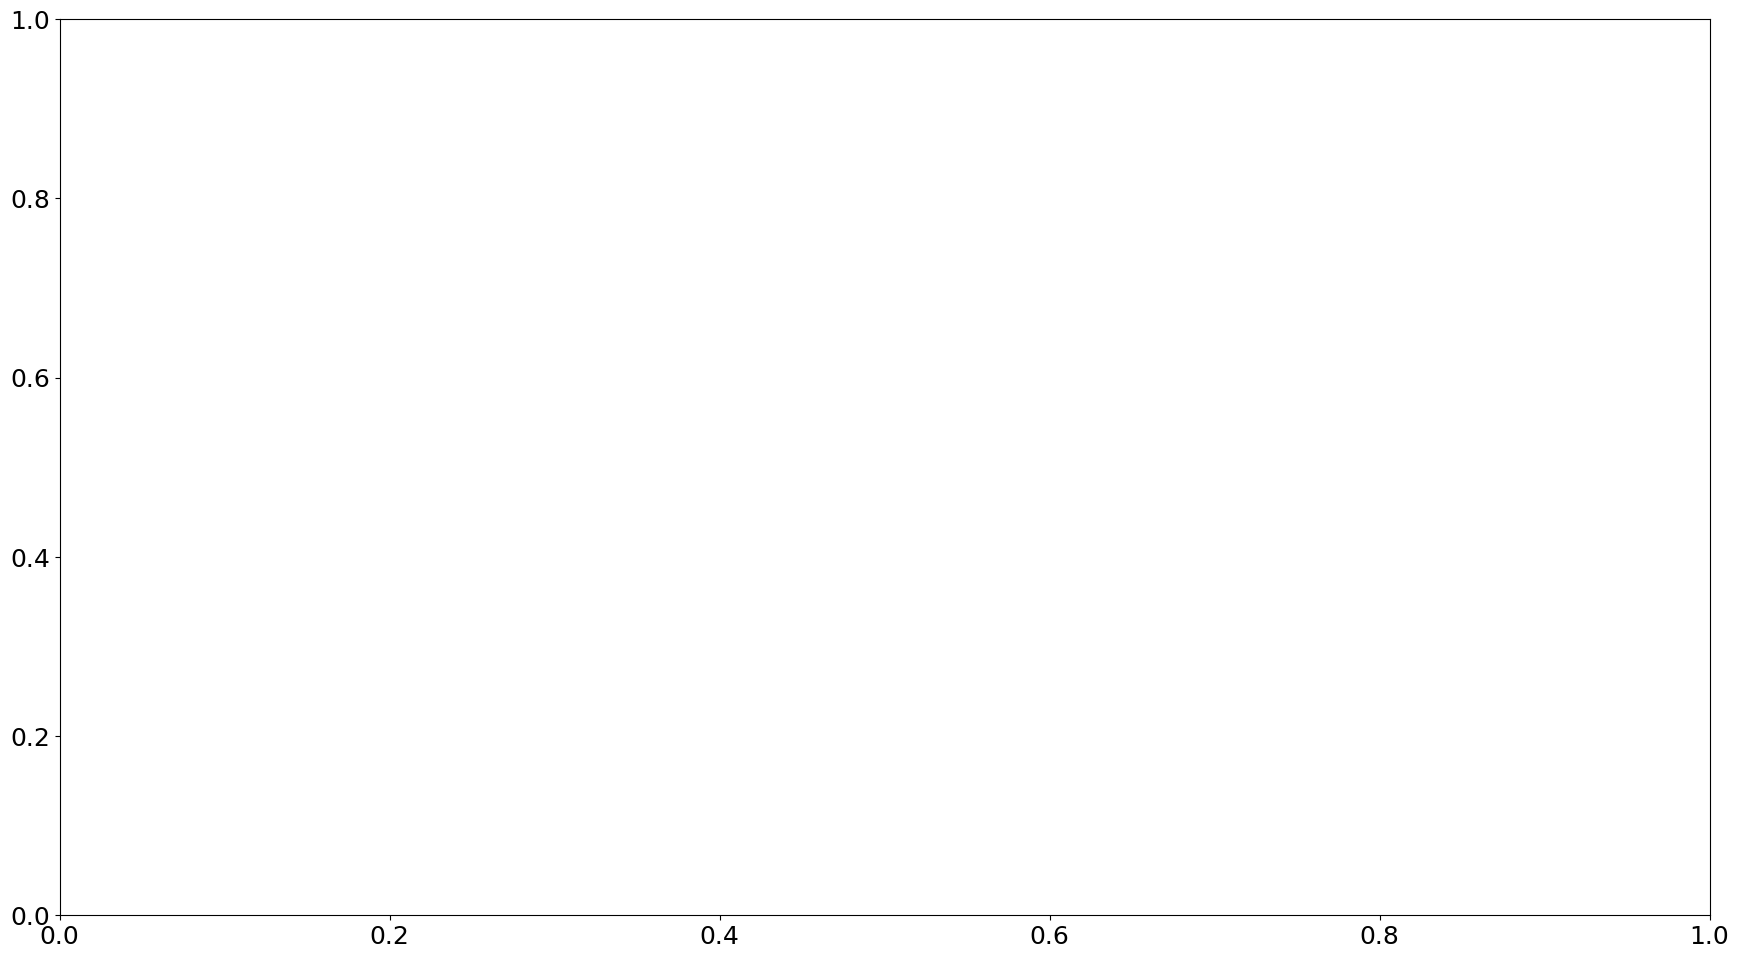

In [2]:
# Training and saving the networks
#for data_set_type in data_set_types:
for data_set_type in ['focus']:
    
    print(50*'=')
    print(f'{data_set_type=}')
    print(50*'-')
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width/phi), subplotpars=subplotpars)
        
    for model_name, lw in  zip(['resnet18', 'resnet50', 'resnet101'], [1, 2, 4]): #, 
        for do_polar, color in zip([True, False], ['b', 'r']):
            print(50*'.')

            # filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}'
            model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

            json_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.json'

            if os.path.isfile(json_filename):
                print(f"Load JSON from pre-trained resnet {json_filename}")
                df_train = pd.read_json(json_filename, orient='index')
                print(f"{model_filename}: accuracy = {df_train['avg_acc_val'][-5:].mean():.3f}")

            elif os.path.isfile(model_filename + '.lock'):
                # we want to have a file but it's locked
                print(f'Path {model_filename} is locked')
                df_train = None

            elif not os.path.isfile(model_filename + '.lock'):
                print(f"Training resnet {model_filename}")
                
                # either we do not need a file or it does not exist (or it's locked)
                touch(model_filename + '.lock') # we want to have a file let's lock it

                args = Params()
                
                if args.do_polar :
                    args.root = f'{DATAROOT}/Imagenet_{data_set_type}_retino' # Directory containing image
                else:
                    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' 
                    
                args.do_polar = do_polar
                
                # get the weights of the network
                data_set_type_prior = 'full' if data_set_type == 'bbox' else 'bbox'
                model_path = get_filename(data_cache, datetag, data_set_type_prior, model_name, do_polar) + '.pt' if data_set_type != 'full' else None
                
                # get the architecture of the network
                print(f"Loading {model_path=}")
                model_retrain = load_model(model_name=model_name, model_path=model_path, do_scratch=args.do_scratch, do_circular=args.do_polar).to(device)

                
                
                do_polar, do_resize, do_mask= False, False, False # Set to False because image already saved with those transformations

                dataloaders = datasets_transforms(args)

                print("Re-training pretrained model...", model_filename)
                print(f"Traning {model_name}, image_size={args.image_size}")
                since = time.time()
                model_retrain, df_train = train_model(args, model_retrain, dataloaders=dataloaders)
                elapsed_time = time.time() - since
                print(f"Training completed in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s")
                print(f"Saving...{model_filename}")
                torch.save(model_retrain.state_dict(), model_filename)
                df_train.to_json(json_filename, orient='index', indent=2)
                if device=='cuda': torch.cuda.empty_cache()

                print()     
                
            if not(df_train is None):
                # import lmfit
                from lmfit import Parameters, Model

                x = df_train['total_image'].values
                y = df_train['avg_acc_val'].values

                # Define the function
                def model(x, acc_max, acc_min, x_50) :
                    return acc_max - (acc_max-acc_min) * np.exp( - x / x_50)

                # Init the sigmoid model as an lmfit Model object 
                mod = Model(model)
                pars = Parameters()
                # Add the initial parameters guesses
                pars.add_many(('acc_max', np.max(y), True,  0.0, 1.),
                            ('x_50', np.max(x)/20, True, 1, np.max(x)),
                            ('acc_min', 1/1000, True,  0.0, 1.))
                # And fit using least-square minimization
                out = mod.fit(y, pars, x=x, nan_policy='omit', max_nfev = 3000)
                # Print the result
                result = f"fitted max accuracy= {out.best_values['acc_max']:.2f}, speed= {out.best_values['x_50']:.1f}"
                print(result)

                df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
                ax = df_train_roll.plot(x='total_image', y='avg_acc', 
                                    c=color, ls='dashed', lw=lw,
                                    grid=True, ax=ax, label='TRAIN: ' + json_filename.strip(data_cache + '/').strip('.json'))    
                ax = df_train_roll.plot(x='total_image', y='avg_acc_val', 
                                    c=color, lw=lw,
                                    grid=True, ax=ax, label='VAL: ' + json_filename.strip(data_cache + '/').strip('.json') + '-' + result)    
                if os.path.isfile(model_filename + '.lock'): os.remove(model_filename + '.lock')

    ax.set_ylim(.15, .85)            
    ax.set_ylim(.05, .95)            
    ax.set_yscale('logit')
    plt.show()
    print(50*'=')